## PLOT RESULTS

In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from pathlib import Path

In [3]:
from synco import run_pipeline, build_pipeline_config

### CONFIG

#### Configuration Parameters Explanation

The configuration dictionary (`CFG`) contains all necessary parameters to run the SYNCO pipeline analysis:

---

#### **Paths Configuration:**
- **"base"**: Main folder containing the pipeline results and data structure
- **"pipeline_runs"**: Specific path to the prediction model output files (DrugLogics / BooLEVARD results)
- **"input"**: Folder with input data files, must include:
    - Experimental synergies file (CSV format with observed drug combinations)
    - Drug profiles and inhibitor information
    - Target mapping files
- **"output"**: Destination folder for analysis outputs. Set to `None` if no file outputs are needed

---

#### **General Configuration:**
- **"cell_lines"**: List of cancer cell lines to analyze (16 colorectal cancer cell lines)
- **"run_date"**: Date identifier for the specific prediction run being analyzed
- **"verbose"**: Boolean flag to enable detailed logging during pipeline execution

---

#### **Analysis Configuration ("compare"):**
- **"prediction_method"**: Algorithm used for synergy predictions ("DrugLogics" OR "BooLEVARD")
- **"threshold"**: Significance threshold for synergy classification (0.001)
- **"synergy_column"**: Column name containing synergy scores in the data
- **"analysis_mode"**: Type of analysis to perform:
  - `"inhibitor_combination"`: Analyze by drug combination pairs
  - `"cell_line"`: Analyze by individual cell lines

---

#### **Advanced Settings (Optional):**
Additional pipeline parameters can be specified in the "advanced" section to override default behaviors for data loading, prediction processing, and metric calculations.

In [4]:
# CONFIG

CFG = {
    "paths": {
        "base": Path("data/DrugLogics"),
        "pipeline_runs": Path("data/DrugLogics/20250804/drabme_out"),
        "input": Path("data/input"),
        "output": None
    },
    "general": {
        "cell_lines": ['SNU81', 'CAR1', 'HT115', 'LS123', 'NCIH508', 'NCIH747', 'NCIH716', 'T84', 'SW1417', 'SW948', 'SW837', 'SW1463', 'SW1116', 'SW620', 'CL11', 'C2BBE1'],
        "run_date": "20250804",
        "verbose": True,
    },
    "compare": {
        "prediction_method": "DrugLogics",
        "threshold": 0.001,
        "synergy_column": "synergy",
        "analysis_mode": "inhibitor_combination"
    }
    # ADVANCE SETTINGS
    # "advanced": {    }
}

# VARIABLES

analysis_mode = CFG["compare"]["analysis_mode"]
prediction_method = CFG["compare"]["prediction_method"]

### BUILD AND EXTRACT RESULTS

In [5]:
# Build pipeline configuration
pipeline_config = build_pipeline_config(CFG)

# Pipeline execution
synco_results = run_pipeline(pipeline_config)

=== COMPARISON SUMMARY ===

Items in experimental data: 11
Items in predicted data: 11
Common items to compare: 11
Skipped from experimental: 0
Skipped from predicted: 0

=== GLOBAL RESULTS ===

Total comparisons: 176
Global matches: 127 (72.16%)
Global mismatches: 49 (27.84%)
Global True Positives: 103
Global True Negatives: 24
Global False Positives: 33
Global False Negatives: 16
Global Accuracy: 72.16%
Global Recall: 86.55%
Global Precision: 75.74%


In [6]:
# Extract cell/combination metrics from the results

if analysis_mode == "cell_line":
    cell_metrics = synco_results['synergy_comparison']

elif analysis_mode == "inhibitor_combination":
    combi_metrics = synco_results['synergy_comparison']
    

In [7]:
# Extract ROC metrics from the results
roc_metrics = synco_results['roc_results']
traces_roc, traces_pr, rocauc_score_list, prauc_score_list, metrics_df = roc_metrics
metrics_df

,cell_line,roc_auc,pr_auc,f1_score,n_positive,n_negative,pred_min
0,CAR1,0.867816,0.985376,0.950820,29.0,3.0,-0.624607
1,LS123,0.703704,0.941948,0.915254,27.0,5.0,-1.435914
2,T84,NaN,NaN,NaN,NaN,NaN,NaN
3,NCIH508,0.910714,0.985969,0.933333,28.0,4.0,-1.169443
4,NCIH716,0.825521,0.919568,0.857143,24.0,8.0,-0.735926
5,NCIH747,0.736979,0.901042,0.857143,24.0,8.0,-0.357622
6,SNU81,0.531250,0.798733,0.857143,24.0,8.0,-0.626208
7,SW620,0.646484,0.571008,0.666667,16.0,16.0,-0.468207
8,SW837,0.586364,0.739268,0.814815,22.0,10.0,-0.230450
9,SW948,0.907051,0.970499,0.896552,26.0,6.0,-1.174535


### RING PLOTS

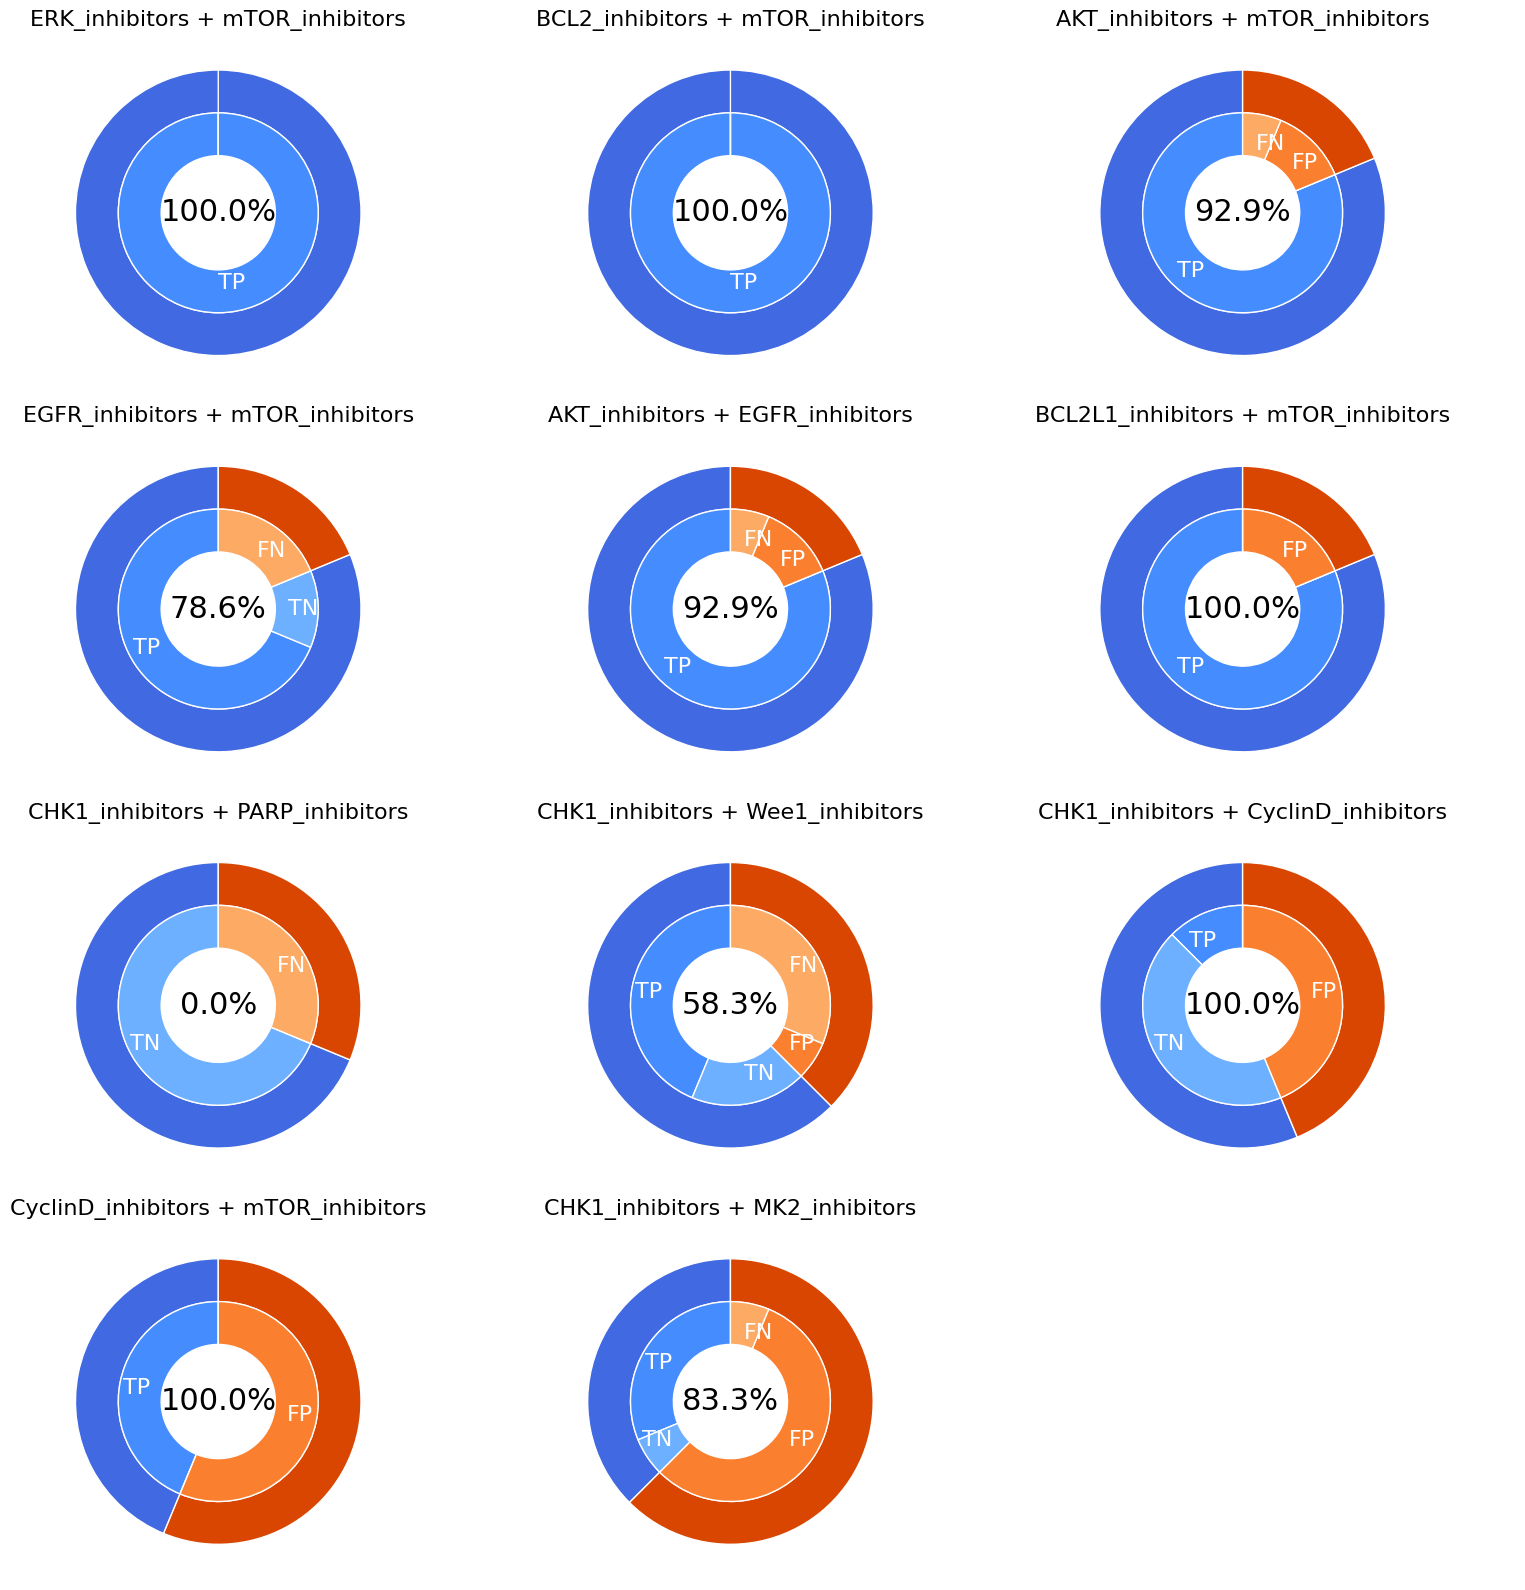

In [8]:
# RING PLOT BY DRUG COMBINATION /////////////////////////////////////////////

def plot_combination_rings(ax, row):
    ax.set_aspect('equal')

    # Outer ring (Match / Mismatch)
    outer_values = [row['Match'], row['Mismatch']]
    outer_colors = ["royalblue", "#D94602"]

    ax.pie(
        outer_values,
        radius=1,
        startangle=90,
        colors=outer_colors,
        # labels=['Match', 'Mismatch'],
        wedgeprops=dict(width=0.3, edgecolor='w'),
    )

    # Inner ring (TP / TN / FP / FN)
    inner_values = [row['True Positive'], row['True Negative'], row['False Positive'], row['False Negative']]
    inner_values = [int(value) for value in inner_values]
    inner_colors = ["#458cff", "#6db0ff", "#FA7F2E", "#FDAA65"]

    # Add labels for the inner ring if there are more than 0 values
    labels = ['TP', 'TN', 'FP', 'FN']
    for i, value in enumerate(inner_values):
        if value > 0:
            labels[i] = f"{labels[i]}"
        elif value == 0:
            labels[i] = ''

    ax.pie(
        inner_values,
        radius=0.7,
        startangle=90,
        colors=inner_colors,
        labels=labels,
        labeldistance=0.7,
        textprops={'color': 'w', 'fontsize': 16},
        wedgeprops=dict(width=0.3, edgecolor='w')
    )

    # Central text
    ax.text(0, 0, f"{row['Recall']:.1f}%", ha='center', va='center', fontsize=22)

    # Title
    ax.set_title(f"{row.name}", fontsize=16)

# Create conditional to check if combi_metrics exists, if not print "run config with inhibitor_combination mode"
if 'combi_metrics' not in locals():
    print("Run config with analysis_mode = inhibitor_combination")
elif combi_metrics is None:
    print("Run config with analysis_mode = inhibitor_combination")
else:
    # Plot all target combinations in a grid
    fig, axes = plt.subplots(4, 3, figsize=(16, 16))
    axes = axes.flatten()

    # Sort combi_match_df by Recall
    combi_match_df = combi_metrics.sort_values(by='Accuracy', ascending=False)

    for ax, (_, row) in zip(axes, combi_match_df.iterrows()):
        plot_combination_rings(ax, row)

    # Hide any unused subplots
    for ax in axes[len(combi_match_df):]:
        ax.axis('off')

    # Add legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Correct prediction', markerfacecolor='royalblue', markersize=15),
        Line2D([0], [0], marker='o', color='w', label='Missed prediction', markerfacecolor='#D94602', markersize=15),
        Line2D([0], [0], marker='o', color='w', label='True Positives', markerfacecolor='#458cff', markersize=15),
        Line2D([0], [0], marker='o', color='w', label='True Negatives', markerfacecolor='#6db0ff', markersize=15),
        Line2D([0], [0], marker='o', color='w', label='False Positives', markerfacecolor='#FA7F2E', markersize=15),
        Line2D([0], [0], marker='o', color='w', label='False Negatives', markerfacecolor='#FDAA65', markersize=15),
        Line2D([0], [0], marker='o', color='w', label='% Recall', markerfacecolor='w', markersize=15),
    ]

    # Top right outside the plot
    # fig.legend(handles=legend_elements, fontsize=14, loc='lowe right', bbox_to_anchor=(1.1, 0.9))

    plt.tight_layout()
    # plt.savefig(f"{plots_path}rings_combination.png", bbox_inches='tight')
    plt.show()

In [9]:
# RING PLOT BY CELL LINE /////////////////////////////////////////////

# cell_line_match_df.columns
def plot_cell_line_rings(ax, row):
    ax.set_aspect('equal')

    # Outer ring (Match / Mismatch)
    outer_values = [row['Match'], row['Mismatch']]
    outer_colors = ["royalblue", "#D94602"]

    ax.pie(
        outer_values,
        radius=1,
        startangle=90,
        colors=outer_colors,
        # labels=['Match', 'Mismatch'],
        wedgeprops=dict(width=0.3, edgecolor='w'),
        textprops={'fontsize': 14}
    )

    # Inner ring (TP / TN / FP / FN)
    inner_values = [row['True Positive'], row['True Negative'], row['False Positive'], row['False Negative']]
    inner_values = [int(value) for value in inner_values]
    inner_colors = ["#458cff", "#6db0ff", "#FA7F2E", "#FDAA65"]

    # Add labels for the inner ring if there are more than 0 values
    labels = ['TP', 'TN', 'FP', 'FN']
    for i, value in enumerate(inner_values):
        if value > 0:
            labels[i] = f"{labels[i]}"
        elif value == 0:
            labels[i] = ''

    ax.pie(
        inner_values,
        radius=0.7,
        startangle=90,
        colors=inner_colors,
        labels=labels,
        labeldistance=0.7,
        textprops={'color': 'w', 'fontsize': 16},
        wedgeprops=dict(width=0.3, edgecolor='w')
    )

    # Central text
    ax.text(0, 0, f"{row['Recall']:.1f}%", ha='center', va='center', fontsize=18)

    # Title
    ax.set_title(f"{row.name}", fontsize=20, pad=5)

# Create conditional to check if cell_metrics exists, if not print "run config with cell line mode"
if 'cell_metrics' not in locals():
    print("Run config with analysis_mode = cell_line")
elif cell_metrics is None:
    print("Run config with analysis_mode = cell_line")
else:
    # Plot all cell lines in a grid
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    axes = axes.flatten()

    # Sort the DataFrame by Accuracy
    cell_line_match_df = cell_metrics.sort_values(by='Accuracy', ascending=False)

    for ax, (_, row) in zip(axes, cell_line_match_df.iterrows()):
        plot_cell_line_rings(ax, row)

    # Hide any unused subplots
    for ax in axes[len(cell_line_match_df):]:
        ax.axis('off')

    # # Add legend
    # legend_elements = [
    #     Line2D([0], [0], marker='o', color='w', label='Correct prediction', markerfacecolor='royalblue', markersize=15),
    #     Line2D([0], [0], marker='o', color='w', label='Missed prediction', markerfacecolor='#D94602', markersize=15),
    #     Line2D([0], [0], marker='o', color='w', label='True Positives', markerfacecolor='#458cff', markersize=15),
    #     Line2D([0], [0], marker='o', color='w', label='True Negatives', markerfacecolor='#6db0ff', markersize=15),
    #     Line2D([0], [0], marker='o', color='w', label='False Positives', markerfacecolor='#FA7F2E', markersize=15),
    #     Line2D([0], [0], marker='o', color='w', label='False Negatives', markerfacecolor='#FDAA65', markersize=15),
    #     Line2D([0], [0], marker='o', color='w', label='% Recall', markerfacecolor='w', markersize=15),
    # ]
    # # Top right outside the plot
    # fig.legend(handles=legend_elements, fontsize=16, loc='upper right', bbox_to_anchor=(1.1, 1))

    plt.tight_layout()
    # plt.savefig(f"{plots_path}rings_cell_lines.png", bbox_inches='tight')
    plt.show()

Run config with analysis_mode = cell_line


### ROC AUC

In [10]:
# Get plot_curves from features.plot_roc_metrics
from synco.features.plot_roc_metrics import plot_curves

# Plot ROC and PR curves
plot_curves(
    traces=traces_roc,
    auc_score_list=rocauc_score_list,
    model="neko_oncologics",
    specific_date="20250804",
    tissue='all',
    metric='ROC',
)
